In [ ]:
# Check GPU
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Upload your zip file
from google.colab import files
uploaded = files.upload()  # archive_(3).zip select කරන්න

Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile, os

with zipfile.ZipFile('archive (3).zip', 'r') as z:
    z.extractall('dataset')

print("Train folders:", os.listdir('dataset/train'))
print("Valid folders:", os.listdir('dataset/valid'))

Train folders: ['Ladybird Mimic Spider', 'Blue Tarantula', 'Peacock Spider', 'Brown Grass Spider', 'Spiny-backed Orb-weaver', 'Golden Orb Weaver', 'Hobo Spider', 'Brown Recluse Spider', 'Red Knee Tarantula', 'Black Widow', 'Huntsman Spider', 'Yellow Garden Spider', 'Deinopis Spider', 'White Kneed Tarantula', 'Bold Jumper']
Valid folders: ['Ladybird Mimic Spider', 'Blue Tarantula', 'Peacock Spider', 'Brown Grass Spider', 'Spiny-backed Orb-weaver', 'Golden Orb Weaver', 'Hobo Spider', 'Brown Recluse Spider', 'Red Knee Tarantula', 'Black Widow', 'Huntsman Spider', 'Yellow Garden Spider', 'Deinopis Spider', 'White Kneed Tarantula', 'Bold Jumper']


In [ ]:
# Configuration
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 30

TRAIN_DIR = 'dataset/train'
VAL_DIR = 'dataset/valid'

NUM_CLASSES = 15  # spider වර්ග 15යි

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of classes: {NUM_CLASSES}")

Image size: 150x150
Batch size: 32
Epochs: 30
Number of classes: 15


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training Generator - augmentation සහිතව
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation Generator - normalize විතරයි
val_datagen = ImageDataGenerator(rescale=1./255)

# Load Training Images
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # 15 classes නිසා categorical
)

# Load Validation Images
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Class mapping:", train_gen.class_indices)

Found 2185 images belonging to 15 classes.
Found 75 images belonging to 15 classes.
Class mapping: {'Black Widow': 0, 'Blue Tarantula': 1, 'Bold Jumper': 2, 'Brown Grass Spider': 3, 'Brown Recluse Spider': 4, 'Deinopis Spider': 5, 'Golden Orb Weaver': 6, 'Hobo Spider': 7, 'Huntsman Spider': 8, 'Ladybird Mimic Spider': 9, 'Peacock Spider': 10, 'Red Knee Tarantula': 11, 'Spiny-backed Orb-weaver': 12, 'White Kneed Tarantula': 13, 'Yellow Garden Spider': 14}


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # First Convolution
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    # Second Convolution
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third Convolution
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Dense Layer
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer - 15 classes නිසා softmax
    layers.Dense(15, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # 15 classes නිසා
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,041,359 (72.64 MB)

 Trainable params: 19,041,359 (72.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save Best Model
checkpoint = ModelCheckpoint(
    'best_spider_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

# Train!
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 307ms/step - accuracy: 0.1483 - loss: 2.6280 - val_accuracy: 0.3600 - val_loss: 2.0742
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 229ms/step - accuracy: 0.2961 - loss: 2.1162 - val_accuracy: 0.3733 - val_loss: 1.9412
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - accuracy: 0.3735 - loss: 1.8859 - val_accuracy: 0.6533 - val_loss: 1.1995
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - accuracy: 0.4192 - loss: 1.7148 - val_accuracy: 0.6133 - val_loss: 1.0641
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step - accuracy: 0.4522 - loss: 1.6040 - val_accuracy: 0.6267 - val_loss: 1.0757
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.5080 - loss: 1.4663 - val_accuracy: 0.6400 - val_loss: 1.0759
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.5204 - loss: 1.3635 - val_accuracy: 0.6667 - val_loss: 1.2427
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.5524 - loss: 1.3015 - val_accu


Actual: Ladybird Mimic Spider
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step


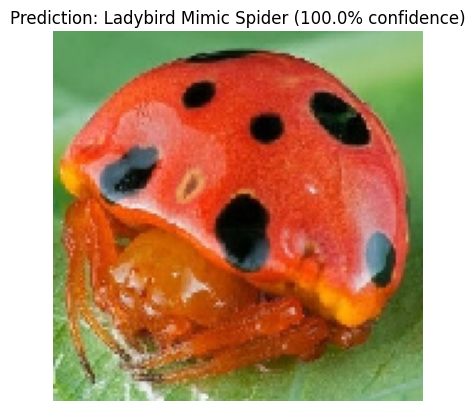

Predicted: Ladybird Mimic Spider
Confidence: 100.0%

Actual: Blue Tarantula
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


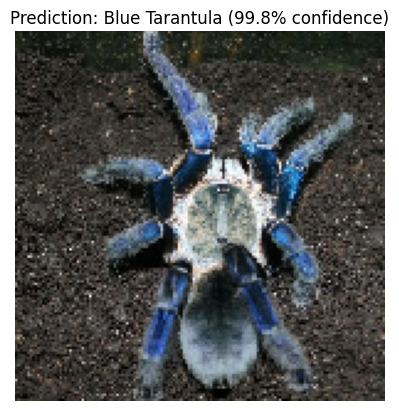

Predicted: Blue Tarantula
Confidence: 99.8%

Actual: Peacock Spider
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


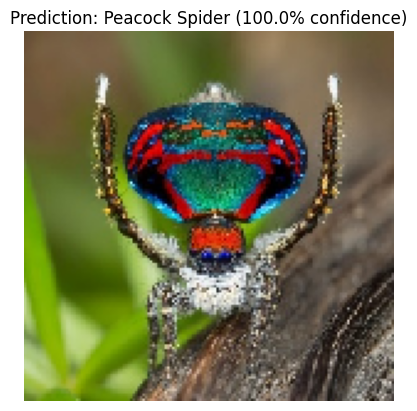

Predicted: Peacock Spider
Confidence: 100.0%

Actual: Brown Grass Spider
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


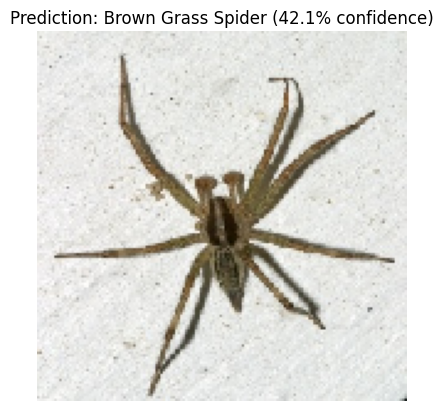

Predicted: Brown Grass Spider
Confidence: 42.1%

Actual: Spiny-backed Orb-weaver
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


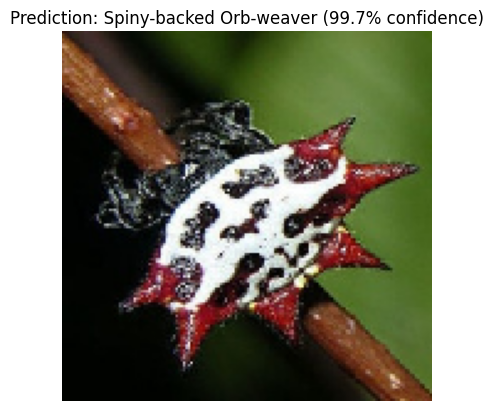

Predicted: Spiny-backed Orb-weaver
Confidence: 99.7%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

def predict_spider(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    class_names = list(train_gen.class_indices.keys())
    label = class_names[class_idx]

    plt.imshow(img)
    plt.title(f'Prediction: {label} ({confidence:.1f}% confidence)')
    plt.axis('off')
    plt.show()

    print(f"Predicted: {label}")
    print(f"Confidence: {confidence:.1f}%")

# Dataset එකේ test images use කරනවා
test_dir = 'dataset/test'
spider_types = os.listdir(test_dir)

# Spider type 5ක් randomly predict කරනවා
for spider in spider_types[:5]:
    img_folder = os.path.join(test_dir, spider)
    img_file = os.listdir(img_folder)[0]
    img_path = os.path.join(img_folder, img_file)
    print(f"\nActual: {spider}")
    predict_spider(img_path)

Saving download (1).jpeg to download (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


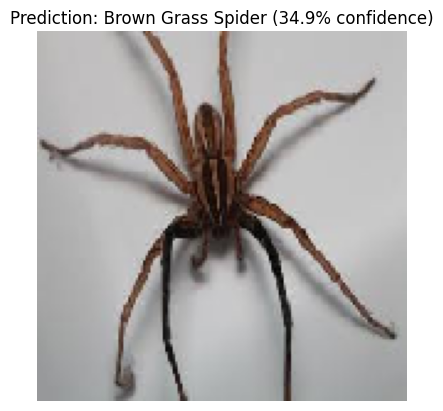

Spider Type: Brown Grass Spider
Confidence: 34.9%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_spider(img_path):
    # Load & resize
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    # Convert to numbers
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Get label
    class_names = list(train_gen.class_indices.keys())
    label = class_names[class_idx]

    # Show result
    plt.imshow(img)
    plt.title(f'Prediction: {label} ({confidence:.1f}% confidence)')
    plt.axis('off')
    plt.show()

    print(f"Spider Type: {label}")
    print(f"Confidence: {confidence:.1f}%")

# Test image upload කරන්න
from google.colab import files
uploaded = files.upload()

# Predict
img_name = list(uploaded.keys())[0]
predict_spider(img_name)

In [ ]:
import random

# Test folder එකෙන් random images 5ක් predict කරනවා
test_dir = 'dataset/test'
spider_types = os.listdir(test_dir)

correct = 0
total = 5

for spider in random.sample(spider_types, total):
    img_folder = os.path.join(test_dir, spider)
    img_file = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_file)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    class_names = list(train_gen.class_indices.keys())
    predicted = class_names[class_idx]

    status = "✅" if predicted == spider else "❌"
    print(f"{status} Actual: {spider}")
    print(f"   Predicted: {predicted} ({confidence:.1f}%)\n")
    if predicted == spider:
        correct += 1

print(f"Score: {correct}/{total}")

✅ Actual: Black Widow
   Predicted: Black Widow (92.8%)

✅ Actual: Peacock Spider
   Predicted: Peacock Spider (100.0%)

✅ Actual: Ladybird Mimic Spider
   Predicted: Ladybird Mimic Spider (100.0%)

❌ Actual: Red Knee Tarantula
   Predicted: White Kneed Tarantula (89.0%)

✅ Actual: Golden Orb Weaver
   Predicted: Golden Orb Weaver (74.9%)

Score: 4/5


In [ ]:
model.save('spider_classifier.keras')
print("Model saved! ✅")

Model saved! ✅


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Pre-trained model load කරනවා
base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Pre-trained weights lock කරනවා

# ඔයාගේ spider layers add කරනවා
model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

/tmp/ipykernel_4131/1372393079.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint2 = ModelCheckpoint(
    'best_spider_model_v2.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

history2 = model2.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop2, checkpoint2]
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 613ms/step - accuracy: 0.4700 - loss: 1.7103 - val_accuracy: 0.8533 - val_loss: 0.5311
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.6654 - loss: 1.0156 - val_accuracy: 0.8667 - val_loss: 0.4360
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.7030 - loss: 0.8513 - val_accuracy: 0.8800 - val_loss: 0.3625
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step - accuracy: 0.7304 - loss: 0.7642 - val_accuracy: 0.8800 - val_loss: 0.3397
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step - accuracy: 0.7442 - loss: 0.7260 - val_accuracy: 0.8533 - val_loss: 0.3962
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - accuracy: 0.7716 - loss: 0.6591 - val_accuracy: 0.8667 - val_loss: 0.3272
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - accuracy: 0.7648 - loss: 0.6349 - val_accuracy: 0.8667 - val_loss: 0.3120
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.7808 - loss: 0.6114 - val_accu

In [ ]:
# Evaluate new model
val_loss2, val_acc2 = model2.evaluate(val_gen)
print(f"\nModel 1 Accuracy: 80.00%")
print(f"Model 2 Accuracy: {val_acc2*100:.2f}%")
print(f"Improvement: +{(val_acc2 - 0.80)*100:.2f}%")

# Save
model2.save('spider_classifier_v2.keras')
print("\nModel V2 saved! ✅")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9067 - loss: 0.2409

Model 1 Accuracy: 80.00%
Model 2 Accuracy: 90.67%
Improvement: +10.67%

Model V2 saved! ✅


In [ ]:
# MobileNetV2 layers unlock කරනවා
base_model.trainable = True

# Last 30 layers විතරයි train කරන්නේ
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower learning rate use කරනවා - important!
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint3 = ModelCheckpoint(
    'best_spider_model_v3.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

# Fine-tune!
history3 = model2.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop3, checkpoint3]
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 50s 459ms/step - accuracy: 0.6416 - loss: 1.0465 - val_accuracy: 0.9067 - val_loss: 0.2345
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.7057 - loss: 0.8129 - val_accuracy: 0.8933 - val_loss: 0.2374
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.7414 - loss: 0.7101 - val_accuracy: 0.8933 - val_loss: 0.2412
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.7767 - loss: 0.6471 - val_accuracy: 0.8933 - val_loss: 0.2363
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.7803 - loss: 0.6241 - val_accuracy: 0.8933 - val_loss: 0.2346
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 219ms/step - accuracy: 0.7968 - loss: 0.5756 - val_accuracy: 0.9200 - val_loss: 0.2266
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.8050 - loss: 0.5643 - val_accuracy: 0.9067 - val_loss: 0.2259
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 213ms/step - accuracy: 0.8027 - loss: 0.5607 - val_accu

In [ ]:
val_loss3, val_acc3 = model2.evaluate(val_gen)
print(f"\nModel 1 (Custom CNN):     80.00%")
print(f"Model 2 (Transfer Learn): 90.67%")
print(f"Model 3 (Fine-tuned):     {val_acc3*100:.2f}%")
print(f"\nTotal Improvement: +{(val_acc3 - 0.80)*100:.2f}%")

model2.save('spider_classifier_v3.keras')
print("\nModel V3 saved! ✅")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9067 - loss: 0.2037

Model 1 (Custom CNN):     80.00%
Model 2 (Transfer Learn): 90.67%
Model 3 (Fine-tuned):     90.67%

Total Improvement: +10.67%

Model V3 saved! ✅


In [ ]:
import random

print("=== Final Model Test ===\n")

test_dir = 'dataset/test'
spider_types = os.listdir(test_dir)

correct = 0
total = 10

for spider in random.sample(spider_types, total):
    img_folder = os.path.join(test_dir, spider)
    img_file = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_file)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model2.predict(img_array, verbose=0)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    class_names = list(train_gen.class_indices.keys())
    predicted = class_names[class_idx]

    status = "✅" if predicted == spider else "❌"
    print(f"{status} Actual:    {spider}")
    print(f"   Predicted: {predicted} ({confidence:.1f}%)\n")
    if predicted == spider:
        correct += 1

print(f"{'='*40}")
print(f"Final Score: {correct}/{total} = {correct/total*100:.0f}%")

=== Final Model Test ===

✅ Actual:    Blue Tarantula
   Predicted: Blue Tarantula (100.0%)

✅ Actual:    Huntsman Spider
   Predicted: Huntsman Spider (95.4%)

✅ Actual:    White Kneed Tarantula
   Predicted: White Kneed Tarantula (99.8%)

✅ Actual:    Brown Recluse Spider
   Predicted: Brown Recluse Spider (82.0%)

✅ Actual:    Black Widow
   Predicted: Black Widow (100.0%)

✅ Actual:    Bold Jumper
   Predicted: Bold Jumper (99.9%)

✅ Actual:    Peacock Spider
   Predicted: Peacock Spider (100.0%)

✅ Actual:    Yellow Garden Spider
   Predicted: Yellow Garden Spider (100.0%)

✅ Actual:    Red Knee Tarantula
   Predicted: Red Knee Tarantula (100.0%)

✅ Actual:    Hobo Spider
   Predicted: Hobo Spider (62.6%)

Final Score: 10/10 = 100%


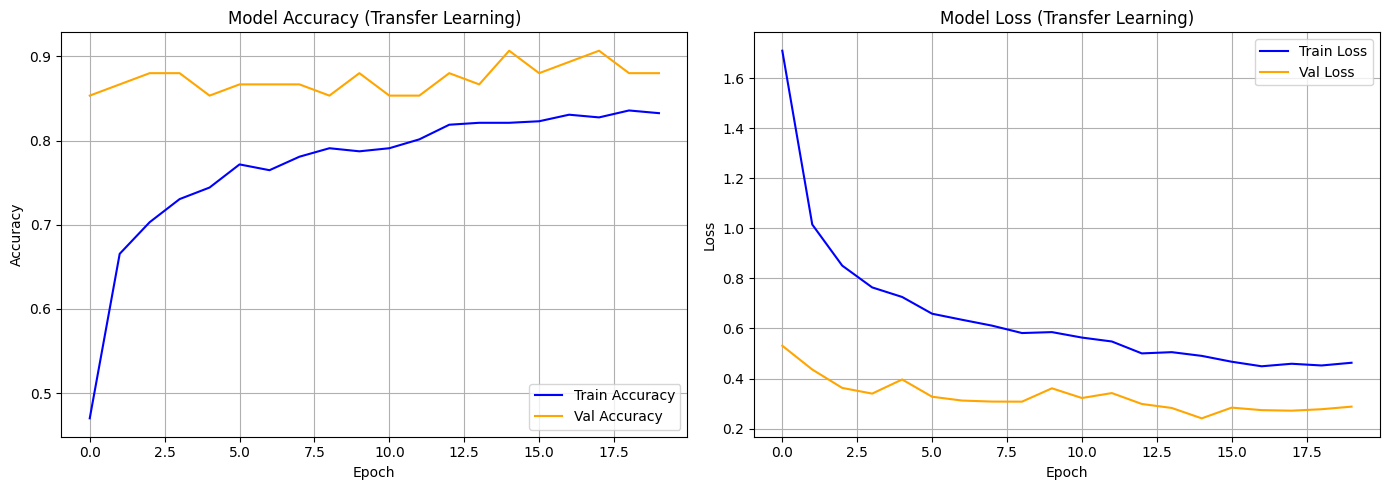

Good Training Signs:
✅ Final Train Accuracy: 83.25%
✅ Final Val Accuracy:   88.00%
✅ Final Train Loss:     0.4631
✅ Final Val Loss:       0.2877


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
ax1.plot(history2.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history2.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy (Transfer Learning)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Graph
ax2.plot(history2.history['loss'], label='Train Loss', color='blue')
ax2.plot(history2.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss (Transfer Learning)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Good Training Signs:")
print(f"✅ Final Train Accuracy: {history2.history['accuracy'][-1]*100:.2f}%")
print(f"✅ Final Val Accuracy:   {history2.history['val_accuracy'][-1]*100:.2f}%")
print(f"✅ Final Train Loss:     {history2.history['loss'][-1]:.4f}")
print(f"✅ Final Val Loss:       {history2.history['val_loss'][-1]:.4f}")

In [ ]:
# Google Drive mount කරනවා
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted! ✅")

Mounted at /content/drive
Drive mounted! ✅


In [ ]:
# Zip file upload කරනවා
from google.colab import files
uploaded = files.upload()  # archive (3).zip select කරන්න

Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile, os

with zipfile.ZipFile('archive (3).zip', 'r') as z:
    z.extractall('dataset')

print("Dataset ready! ✅")
print("Train folders:", os.listdir('dataset/train'))

Dataset ready! ✅
Train folders: ['Ladybird Mimic Spider', 'Blue Tarantula', 'Peacock Spider', 'Brown Grass Spider', 'Spiny-backed Orb-weaver', 'Golden Orb Weaver', 'Hobo Spider', 'Brown Recluse Spider', 'Red Knee Tarantula', 'Black Widow', 'Huntsman Spider', 'Yellow Garden Spider', 'Deinopis Spider', 'White Kneed Tarantula', 'Bold Jumper']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_DIR = 'dataset/train'
VAL_DIR = 'dataset/valid'

# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

# Model
base_model = MobileNetV2(input_shape=(150,150,3), include_top=False, weights='imagenet')
base_model.trainable = False

model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_spider_model_v2.keras',
    save_best_only=True, monitor='val_accuracy'
)

# Train
history = model2.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

print("\nTraining Complete! ✅")

Found 2185 images belonging to 15 classes.
Found 75 images belonging to 15 classes.


/tmp/ipykernel_519/3789797531.py:34: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150,150,3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 74s 756ms/step - accuracy: 0.4513 - loss: 1.7326 - val_accuracy: 0.8000 - val_loss: 0.5386
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.6540 - loss: 0.9938 - val_accuracy: 0.8267 - val_loss: 0.4491
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - accuracy: 0.7039 - loss: 0.8309 - val_accuracy: 0.8667 - val_loss: 0.3508
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.7254 - loss: 0.7790 - val_accuracy: 0.8933 - val_loss: 0.3326
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.7442 - loss: 0.7272 - val_accuracy: 0.8667 - val_loss: 0.3360
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 254ms/step - accuracy: 0.7410 - loss: 0.6992 - val_accuracy: 0.8667 - val_loss: 0.3422
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.7703 - loss: 0.6400 - val_accuracy: 0.8267 - val_loss: 0.3535
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    img_resized = img.resize((150, 150))
    img_array = keras_image.img_to_array(img_resized)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model2.predict(img_array, verbose=0)
    class_names = list(train_gen.class_indices.keys())

    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])

    return results

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(type='pil', label="🕷️ Spider Image Upload කරන්න"),
    outputs=gr.Label(num_top_classes=3, label="Spider Type"),
    title="🕷️ Spider Classifier",
    description="Spider image එකක් upload කරන්න — model එක identify කරනවා!",
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://33cc0f16a293026d6c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Model සහ class names Drive එකට save කරනවා
import json

# Model save කරනවා
model2.save('/content/drive/MyDrive/spider_classifier_final.keras')
print("Model saved to Drive! ✅")

# Class names save කරනවා
class_names = list(train_gen.class_indices.keys())
with open('/content/drive/MyDrive/spider_class_names.json', 'w') as f:
    json.dump(class_names, f)
print("Class names saved to Drive! ✅")
print("\nClass names:", class_names)

Model saved to Drive! ✅
Class names saved to Drive! ✅

Class names: ['Black Widow', 'Blue Tarantula', 'Bold Jumper', 'Brown Grass Spider', 'Brown Recluse Spider', 'Deinopis Spider', 'Golden Orb Weaver', 'Hobo Spider', 'Huntsman Spider', 'Ladybird Mimic Spider', 'Peacock Spider', 'Red Knee Tarantula', 'Spiny-backed Orb-weaver', 'White Kneed Tarantula', 'Yellow Garden Spider']


In [ ]:
# Drive එකෙන් model load කරන code එක — future වලදී use කරන්න
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

# Model load කරනවා
model2 = tf.keras.models.load_model('/content/drive/MyDrive/spider_classifier_final.keras')
print("Model loaded! ✅")

# Class names load කරනවා
with open('/content/drive/MyDrive/spider_class_names.json', 'r') as f:
    class_names = json.load(f)
print("Class names loaded! ✅")
print("Classes:", class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded! ✅
Class names loaded! ✅
Classes: ['Black Widow', 'Blue Tarantula', 'Bold Jumper', 'Brown Grass Spider', 'Brown Recluse Spider', 'Deinopis Spider', 'Golden Orb Weaver', 'Hobo Spider', 'Huntsman Spider', 'Ladybird Mimic Spider', 'Peacock Spider', 'Red Knee Tarantula', 'Spiny-backed Orb-weaver', 'White Kneed Tarantula', 'Yellow Garden Spider']


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    img_resized = img.resize((150, 150))
    img_array = keras_image.img_to_array(img_resized)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model2.predict(img_array, verbose=0)

    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])

    return results

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(type='pil', label="🕷️ Spider Image Upload කරන්න"),
    outputs=gr.Label(num_top_classes=3, label="Spider Type"),
    title="🕷️ Spider Classifier",
    description="Spider image එකක් upload කරන්න — model එක identify කරනවා!",
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8646de1f059954ef3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

model2 = tf.keras.models.load_model('/content/drive/MyDrive/spider_classifier_final.keras')

with open('/content/drive/MyDrive/spider_class_names.json', 'r') as f:
    class_names = json.load(f)

print("Ready! ✅")

Mounted at /content/drive
Ready! ✅


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    img_resized = img.resize((150, 150))
    img_array = keras_image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model2.predict(img_array, verbose=0)
    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])
    return results

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(type='pil', label="🕷️ Spider Image Upload කරන්න"),
    outputs=gr.Label(num_top_classes=3, label="Spider Type"),
    title="🕷️ ArachnoVision",
    description="Spider image එකක් upload කරන්න!",
)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dff98111849b487a7a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    img_resized = img.resize((150, 150))
    img_array = keras_image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model2.predict(img_array, verbose=0)
    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])
    return results

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(type='pil', label="🕷️ Spider Image Upload කරන්න"),
    outputs=gr.Label(num_top_classes=3, label="Spider Type"),
    title="🕷️ ArachnoVision",
    description="Spider image එකක් upload කරන්න!",
)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9daa905ab5a8fd16ec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Colab Notebooks', 'sALSyl SFT.pdf', 'Classroom', 'Day_3_ Assignment.pdf', 'Day_3_Assignment_1 (1).pdf', 'Day_3_Assignment_1.pdf', 'assiment-3 (1).pdf', 'assiment-3.pdf', 'assiment-3-cad-1 (2).dwg', 'assiment-3-cad-1 (1).dwg', 'assiment-3-cad-1.dwg', 'CAD_A2.dwg', 'assigment 4 answer.pdf', '5 day assigment (1).dwg', 'Drawing1 (1).dwg', 'Drawing1.dwg', '5 day assigment.dwg', 'assignment.pdf', 'RANDI.dwg', 'ssignment.dwg', 'assignment10.pdf', 'assignment11.dwg', '14 day assigment (1).dwg', '14 day assigment.dwg', 'Randi_AL.pdf', 'Randi_OL.pdf', 'Randi_NIC.pdf', 'Cash Deposit_Slip.pdf', 'Randi__AL.pdf', 'Signature_Randi.jpg', 'sALSyl SFT.gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'ANUIT2324F013pdf_250406_195148.pdf', 'ANU_IT_2324_F_013 (2).pdf', 'ANU_IT_2324_F_013 (1).pdf', 'ANU_IT_2324_F_013.pdf', 'ANU-IT-2324-F-13 (1).pdf', 'ANU-IT-2324-F-13.pdf', 'ANU-IT-2324-F-013 (1).pdf', 'ANU-IT-2324-F-013.pdf', 'ANU-IT-2324-F-013 13 May 25 · 09·42

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/spider_dataset_100'
print("Folders:", os.listdir(dataset_path))

Folders: ['Araneus_diadematus', 'Pisaura_mirabilis', 'Argiope_bruennichi', 'Phidippus_audax', 'Misumena_vatia', 'Argiope_aurantia', 'Zoropsis_spinimana', 'Salticus_scenicus', 'Marpissa_muscosa', 'Trichonephila_clavipes', 'Nuctenea_umbratica', 'Pholcus_phalangioides', 'Platycryptus_undatus', 'Steatoda_grossa']


In [ ]:
import zipfile, os

print("Unzipping...")
with zipfile.ZipFile('/content/drive/MyDrive/archive (3).zip', 'r') as z:
    z.extractall('dataset')

print("Dataset ready! ✅")

train_dir = 'dataset/train'
print("\n📊 Training Images Count:\n")
total = 0
for spider in sorted(os.listdir(train_dir)):
    count = len(os.listdir(f'{train_dir}/{spider}'))
    total += count
    print(f"{spider}: {count} images")
print(f"\nTotal: {total} images")

Unzipping...
Dataset ready! ✅

📊 Training Images Count:

Black Widow: 122 images
Blue Tarantula: 160 images
Bold Jumper: 189 images
Brown Grass Spider: 136 images
Brown Recluse Spider: 140 images
Deinopis Spider: 120 images
Golden Orb Weaver: 153 images
Hobo Spider: 152 images
Huntsman Spider: 168 images
Ladybird Mimic Spider: 104 images
Peacock Spider: 157 images
Red Knee Tarantula: 127 images
Spiny-backed Orb-weaver: 154 images
White Kneed Tarantula: 126 images
Yellow Garden Spider: 177 images

Total: 2185 images


In [ ]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from PIL import Image
import numpy as np

TARGET = 200  # හැම class එකකටම images 200

train_dir = 'dataset/train'
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

for spider in os.listdir(train_dir):
    folder = f'{train_dir}/{spider}'
    images = os.listdir(folder)
    current = len(images)
    needed = TARGET - current

    if needed <= 0:
        print(f"✅ {spider}: {current} images (OK)")
        continue

    print(f"🔄 {spider}: {current} → adding {needed} images...")

    count = 0
    while count < needed:
        img_name = images[count % len(images)]
        img_path = f'{folder}/{img_name}'

        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        for batch in datagen.flow(img_array, batch_size=1,
                                   save_to_dir=folder,
                                   save_prefix='aug',
                                   save_format='jpg'):
            count += 1
            break

    print(f"✅ {spider}: {len(os.listdir(folder))} images")

print("\n🎉 Balancing Complete!")

🔄 Blue Tarantula: 160 → adding 40 images...
✅ Blue Tarantula: 200 images
🔄 Spiny-backed Orb-weaver: 154 → adding 46 images...
✅ Spiny-backed Orb-weaver: 200 images
🔄 Brown Recluse Spider: 140 → adding 60 images...
✅ Brown Recluse Spider: 200 images
🔄 White Kneed Tarantula: 126 → adding 74 images...
✅ White Kneed Tarantula: 200 images
🔄 Ladybird Mimic Spider: 104 → adding 96 images...
✅ Ladybird Mimic Spider: 200 images
🔄 Bold Jumper: 189 → adding 11 images...
✅ Bold Jumper: 200 images
🔄 Black Widow: 122 → adding 78 images...
✅ Black Widow: 199 images
🔄 Deinopis Spider: 120 → adding 80 images...
✅ Deinopis Spider: 200 images
🔄 Red Knee Tarantula: 127 → adding 73 images...
✅ Red Knee Tarantula: 200 images
🔄 Peacock Spider: 157 → adding 43 images...
✅ Peacock Spider: 200 images
🔄 Yellow Garden Spider: 177 → adding 23 images...
✅ Yellow Garden Spider: 200 images
🔄 Hobo Spider: 152 → adding 48 images...
✅ Hobo Spider: 200 images
🔄 Huntsman Spider: 168 → adding 32 images...
✅ Huntsman Spider

In [ ]:
import os

train_dir = 'dataset/train'
print("📊 Balanced Training Images:\n")
total = 0
for spider in sorted(os.listdir(train_dir)):
    count = len(os.listdir(f'{train_dir}/{spider}'))
    total += count
    print(f"{spider}: {count} images")
print(f"\nTotal: {total} images")

📊 Balanced Training Images:

Black Widow: 199 images
Blue Tarantula: 200 images
Bold Jumper: 200 images
Brown Grass Spider: 200 images
Brown Recluse Spider: 200 images
Deinopis Spider: 200 images
Golden Orb Weaver: 200 images
Hobo Spider: 200 images
Huntsman Spider: 200 images
Ladybird Mimic Spider: 200 images
Peacock Spider: 200 images
Red Knee Tarantula: 200 images
Spiny-backed Orb-weaver: 200 images
White Kneed Tarantula: 200 images
Yellow Garden Spider: 200 images

Total: 2999 images


In [ ]:
import zipfile, os
from google.colab import drive
drive.mount('/content/drive')

# Unzip
print("Unzipping...")
with zipfile.ZipFile('/content/drive/MyDrive/archive (3).zip', 'r') as z:
    z.extractall('dataset')
print("Dataset ready! ✅")

Mounted at /content/drive
Unzipping...
Dataset ready! ✅


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

TARGET = 200

train_dir = 'dataset/train'
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

for spider in os.listdir(train_dir):
    folder = f'{train_dir}/{spider}'
    images = os.listdir(folder)
    current = len(images)
    needed = TARGET - current

    if needed <= 0:
        print(f"✅ {spider}: {current} images (OK)")
        continue

    print(f"🔄 {spider}: {current} → adding {needed} images...")

    count = 0
    while count < needed:
        img_name = images[count % len(images)]
        img_path = f'{folder}/{img_name}'

        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        for batch in datagen.flow(img_array, batch_size=1,
                                   save_to_dir=folder,
                                   save_prefix='aug',
                                   save_format='jpg'):
            count += 1
            break

print("\n🎉 Balancing Complete!")

🔄 Peacock Spider: 157 → adding 43 images...
🔄 Hobo Spider: 152 → adding 48 images...
🔄 Blue Tarantula: 160 → adding 40 images...
🔄 Black Widow: 122 → adding 78 images...
🔄 Brown Recluse Spider: 140 → adding 60 images...
🔄 White Kneed Tarantula: 126 → adding 74 images...
🔄 Deinopis Spider: 120 → adding 80 images...
🔄 Red Knee Tarantula: 127 → adding 73 images...
🔄 Ladybird Mimic Spider: 104 → adding 96 images...
🔄 Yellow Garden Spider: 177 → adding 23 images...
🔄 Golden Orb Weaver: 153 → adding 47 images...
🔄 Spiny-backed Orb-weaver: 154 → adding 46 images...
🔄 Bold Jumper: 189 → adding 11 images...
🔄 Brown Grass Spider: 136 → adding 64 images...
🔄 Huntsman Spider: 168 → adding 32 images...

🎉 Balancing Complete!


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

TARGET_VALID = 50  # class එකකට 50 images

valid_dir = 'dataset/valid'
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

for spider in os.listdir(valid_dir):
    folder = f'{valid_dir}/{spider}'
    if not os.path.isdir(folder):
        continue
    images = os.listdir(folder)
    current = len(images)
    needed = TARGET_VALID - current

    if needed <= 0:
        print(f"✅ {spider}: {current} images (OK)")
        continue

    print(f"🔄 {spider}: {current} → adding {needed} images...")

    count = 0
    while count < needed:
        img_name = images[count % len(images)]
        img_path = f'{folder}/{img_name}'

        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        for batch in datagen.flow(img_array, batch_size=1,
                                   save_to_dir=folder,
                                   save_prefix='aug',
                                   save_format='jpg'):
            count += 1
            break

print("\n🎉 Validation Balancing Complete!")

# Count check
print("\n📊 Validation Images Count:\n")
total = 0
for spider in sorted(os.listdir(valid_dir)):
    folder = f'{valid_dir}/{spider}'
    if os.path.isdir(folder):
        count = len(os.listdir(folder))
        total += count
        print(f"{spider}: {count} images")
print(f"\nTotal: {total} images")

🔄 Peacock Spider: 5 → adding 45 images...
🔄 Hobo Spider: 5 → adding 45 images...
🔄 Blue Tarantula: 5 → adding 45 images...
🔄 Black Widow: 5 → adding 45 images...
🔄 Brown Recluse Spider: 5 → adding 45 images...
🔄 White Kneed Tarantula: 5 → adding 45 images...
🔄 Deinopis Spider: 5 → adding 45 images...
🔄 Red Knee Tarantula: 5 → adding 45 images...
🔄 Ladybird Mimic Spider: 5 → adding 45 images...
🔄 Yellow Garden Spider: 5 → adding 45 images...
🔄 Golden Orb Weaver: 5 → adding 45 images...
🔄 Spiny-backed Orb-weaver: 5 → adding 45 images...
🔄 Bold Jumper: 5 → adding 45 images...
🔄 Brown Grass Spider: 5 → adding 45 images...
🔄 Huntsman Spider: 5 → adding 45 images...

🎉 Validation Balancing Complete!

📊 Validation Images Count:

Black Widow: 49 images
Blue Tarantula: 50 images
Bold Jumper: 50 images
Brown Grass Spider: 50 images
Brown Recluse Spider: 50 images
Deinopis Spider: 50 images
Golden Orb Weaver: 50 images
Hobo Spider: 50 images
Huntsman Spider: 50 images
Ladybird Mimic Spider: 50 im

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_DIR = 'dataset/train'
VAL_DIR = 'dataset/valid'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model3 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_spider_efficientnet.keras',
    save_best_only=True, monitor='val_accuracy'
)

history3 = model3.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

print("\nTraining Complete! ✅")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
with zipfile.ZipFile('/content/drive/MyDrive/archive (3).zip', 'r') as z:
    z.extractall('dataset')
print("Dataset ready! ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ready! ✅


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

TARGET = 200
train_dir = 'dataset/train'
valid_dir = 'dataset/valid'

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Train balance
for spider in os.listdir(train_dir):
    folder = f'{train_dir}/{spider}'
    images = os.listdir(folder)
    current = len(images)
    needed = TARGET - current
    if needed <= 0:
        continue
    count = 0
    while count < needed:
        img_name = images[count % len(images)]
        img = load_img(f'{folder}/{img_name}', target_size=(224, 224))
        img_array = np.expand_dims(img_to_array(img), axis=0)
        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=folder, save_prefix='aug', save_format='jpg'):
            count += 1
            break

# Valid balance
for spider in os.listdir(valid_dir):
    folder = f'{valid_dir}/{spider}'
    if not os.path.isdir(folder):
        continue
    images = os.listdir(folder)
    current = len(images)
    needed = 50 - current
    if needed <= 0:
        continue
    count = 0
    while count < needed:
        img_name = images[count % len(images)]
        img = load_img(f'{folder}/{img_name}', target_size=(224, 224))
        img_array = np.expand_dims(img_to_array(img), axis=0)
        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=folder, save_prefix='aug', save_format='jpg'):
            count += 1
            break

print("Balancing Complete! ✅")

Balancing Complete! ✅


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_DIR = 'dataset/train'
VAL_DIR = 'dataset/valid'

# EfficientNet වලට rescale කරන්න ඕනෑ නෑ!
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model3 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_spider_efficientnet.keras',
    save_best_only=True, monitor='val_accuracy'
)

history3 = model3.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

print("\nTraining Complete! ✅")

Found 3000 images belonging to 15 classes.
Found 750 images belonging to 15 classes.
Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 91s 730ms/step - accuracy: 0.6533 - loss: 1.1586 - val_accuracy: 0.9440 - val_loss: 0.4738
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 424ms/step - accuracy: 0.8103 - loss: 0.5884 - val_accuracy: 0.9373 - val_loss: 0.2447
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.8450 - loss: 0.4675 - val_accuracy: 0.9560 - val_loss: 0.1641
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 421ms/step - accuracy: 0.8640 - loss: 0.4024 - val_accuracy: 0.9533 - val_loss: 0.1578
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 409ms/step - accuracy: 0.8760 - loss: 0.3432 - val_accuracy: 0.9547 - val_loss: 0.1441
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.8913 - loss: 0.3067 - val_accuracy: 0.9587 - val_loss: 0.1201
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 425ms/step - accuracy: 0.8977 - loss: 0.2967 - val_accuracy: 0.9427 - val_loss: 0.1446
Epoch 8/30
9

In [ ]:
import json

# Evaluate
val_loss, val_acc = model3.evaluate(val_gen)
print(f"\nFinal Accuracy: {val_acc*100:.2f}%")

# Save
model3.save('/content/drive/MyDrive/spider_efficientnet_final.keras')

class_names = list(train_gen.class_indices.keys())
with open('/content/drive/MyDrive/spider_class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Model saved to Drive! ✅")

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9720 - loss: 0.0975

Final Accuracy: 97.20%
Model saved to Drive! ✅


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    img_resized = img.resize((224, 224))
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array, verbose=0)

    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])

    return results

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(type='pil', label="🕷️ Spider Image Upload කරන්න"),
    outputs=gr.Label(num_top_classes=3, label="Spider Type"),
    title="🕷️ ArachnoVision",
    description="Spider image එකක් upload කරන්න — 97.20% accuracy!",
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7760d9090a325ae0f5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    if img is None:
        return {}
    img_resized = img.resize((224, 224))
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array, verbose=0)

    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])

    return results

css = """
body {
    background-color: #f0f4ff !important;
    font-family: 'Segoe UI', sans-serif;
}

.gradio-container {
    max-width: 900px !important;
    margin: auto !important;
    background: white !important;
    border-radius: 20px !important;
    box-shadow: 0 4px 20px rgba(0,0,255,0.1) !important;
    padding: 30px !important;
}

h1 {
    color: #1a3c8f !important;
    text-align: center !important;
    font-size: 2.5em !important;
    font-weight: 800 !important;
}

.description {
    color: #4a6fa5 !important;
    text-align: center !important;
    font-size: 1.1em !important;
}

button.primary {
    background: linear-gradient(135deg, #1a3c8f, #4a90e2) !important;
    color: white !important;
    border-radius: 10px !important;
    font-size: 1.1em !important;
    padding: 12px 30px !important;
}

.label-container {
    background: #f0f4ff !important;
    border-radius: 10px !important;
    padding: 15px !important;
}
"""

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(
        type='pil',
        label="Upload Spider Image",
    ),
    outputs=gr.Label(
        num_top_classes=3,
        label="🔍 Identified Spider"
    ),
    title="🕷️ ArachnoVision",
    description="### AI-Powered Spider Identification System\nUpload a spider image and our model will identify the species with **97.20% accuracy!**",
    css=css,
    theme=gr.themes.Base(
        primary_hue="blue",
        secondary_hue="indigo",
        neutral_hue="slate",
    ).set(
        button_primary_background_fill="linear-gradient(135deg, #1a3c8f, #4a90e2)",
        button_primary_text_color="white",
        block_title_text_color="#1a3c8f",
        block_label_text_color="#4a6fa5",
    )
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://42fb959804e149cf59.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Predicting...


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 377ms/step


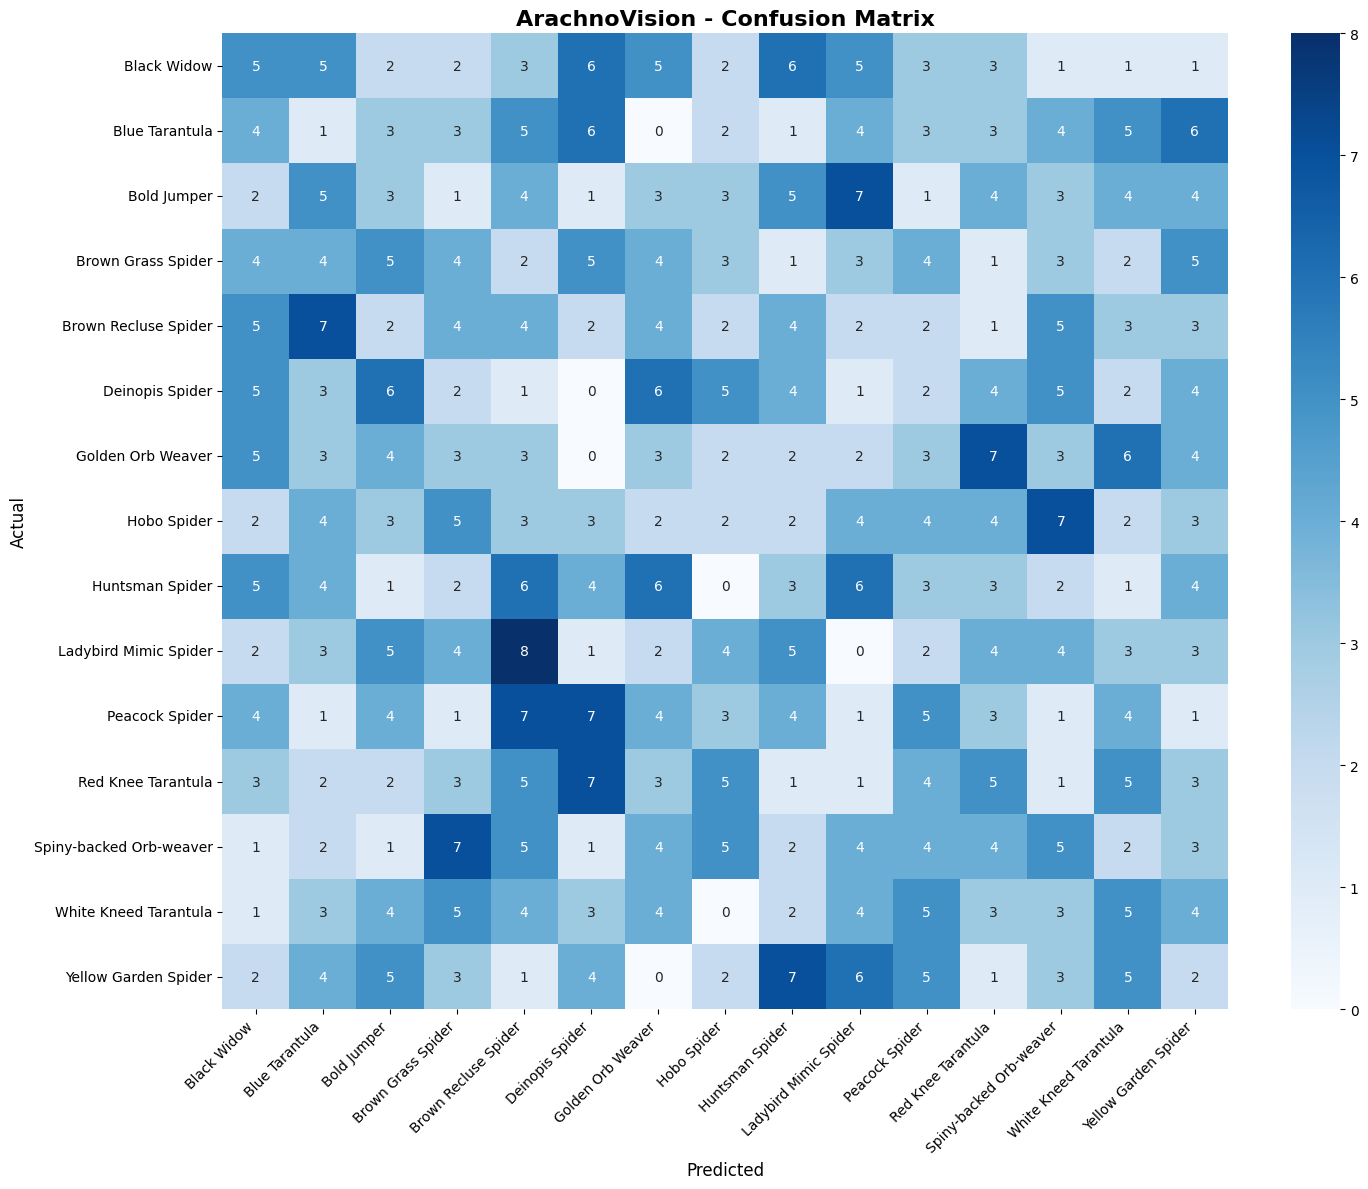


✅ Confusion Matrix saved to Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
print("Predicting...")
val_gen.reset()
predictions = model3.predict(val_gen, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('ArachnoVision - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

print("\n✅ Confusion Matrix saved to Drive!")

Found 750 images belonging to 15 classes.
Predicting...
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step


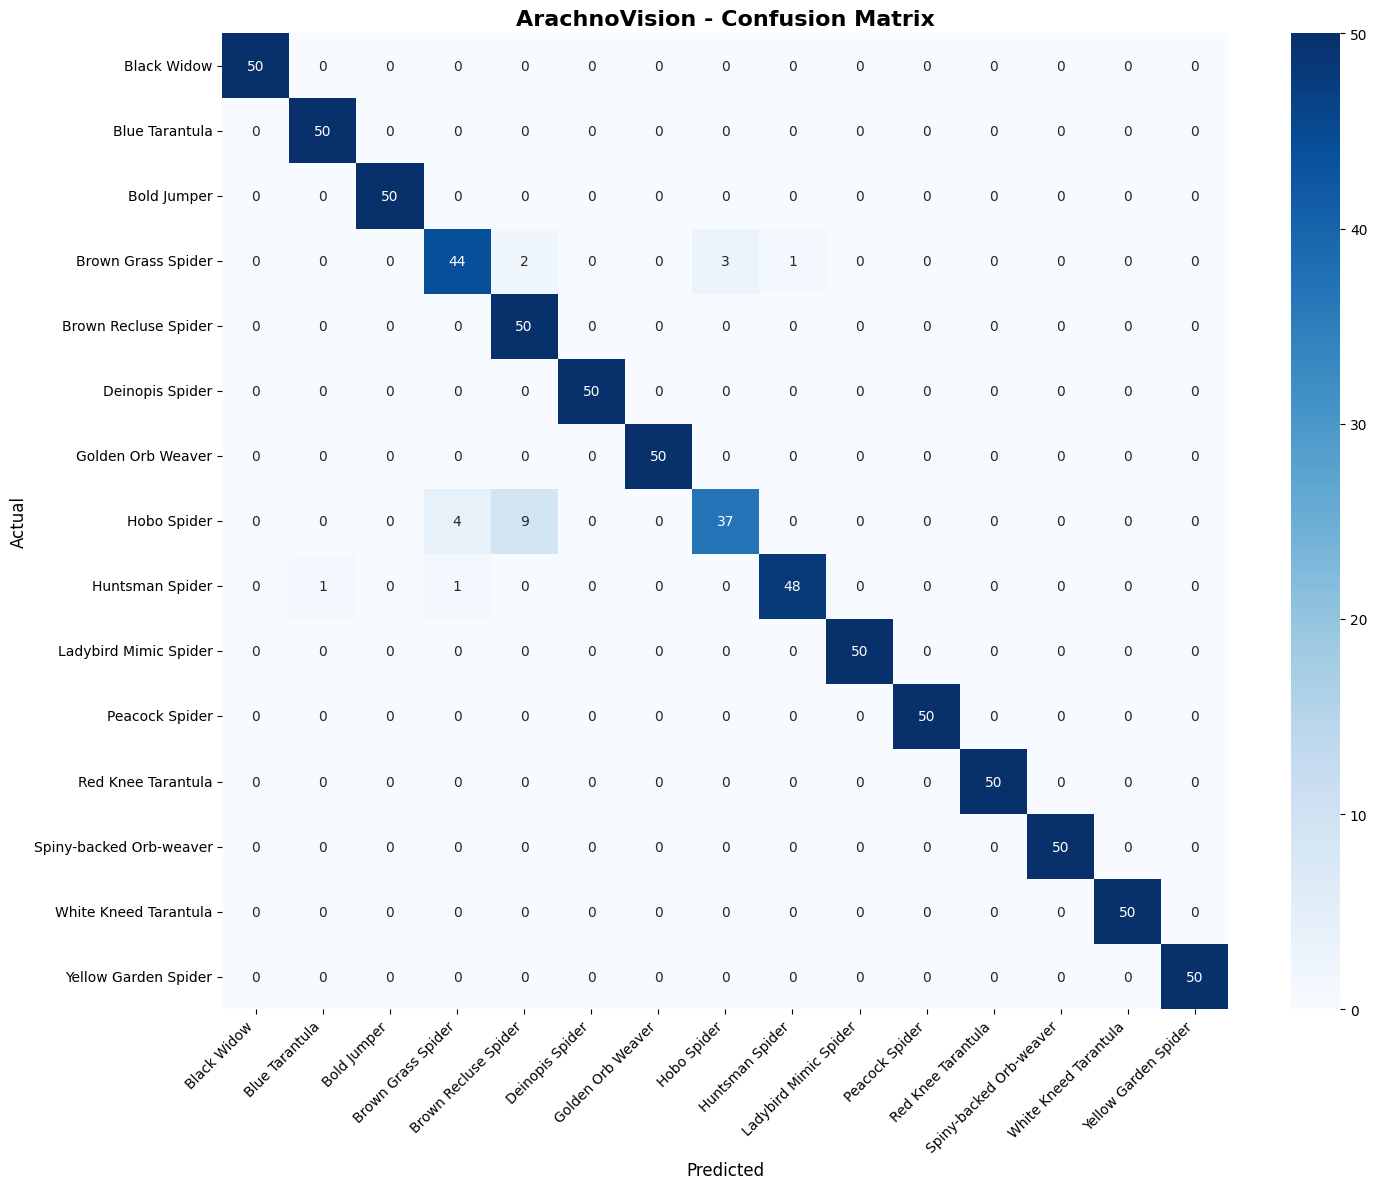


📊 Classification Report:
                         precision    recall  f1-score   support

            Black Widow       1.00      1.00      1.00        50
         Blue Tarantula       0.98      1.00      0.99        50
            Bold Jumper       1.00      1.00      1.00        50
     Brown Grass Spider       0.90      0.88      0.89        50
   Brown Recluse Spider       0.82      1.00      0.90        50
        Deinopis Spider       1.00      1.00      1.00        50
      Golden Orb Weaver       1.00      1.00      1.00        50
            Hobo Spider       0.93      0.74      0.82        50
        Huntsman Spider       0.98      0.96      0.97        50
  Ladybird Mimic Spider       1.00      1.00      1.00        50
         Peacock Spider       1.00      1.00      1.00        50
     Red Knee Tarantula       1.00      1.00      1.00        50
Spiny-backed Orb-weaver       1.00      1.00      1.00        50
  White Kneed Tarantula       1.00      1.00      1.00        5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fresh val generator - shuffle=False important!
val_datagen_fresh = ImageDataGenerator()
val_gen_fresh = val_datagen_fresh.flow_from_directory(
    'dataset/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Predict
print("Predicting...")
predictions = model3.predict(val_gen_fresh, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen_fresh.classes
class_names = list(val_gen_fresh.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('ArachnoVision - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

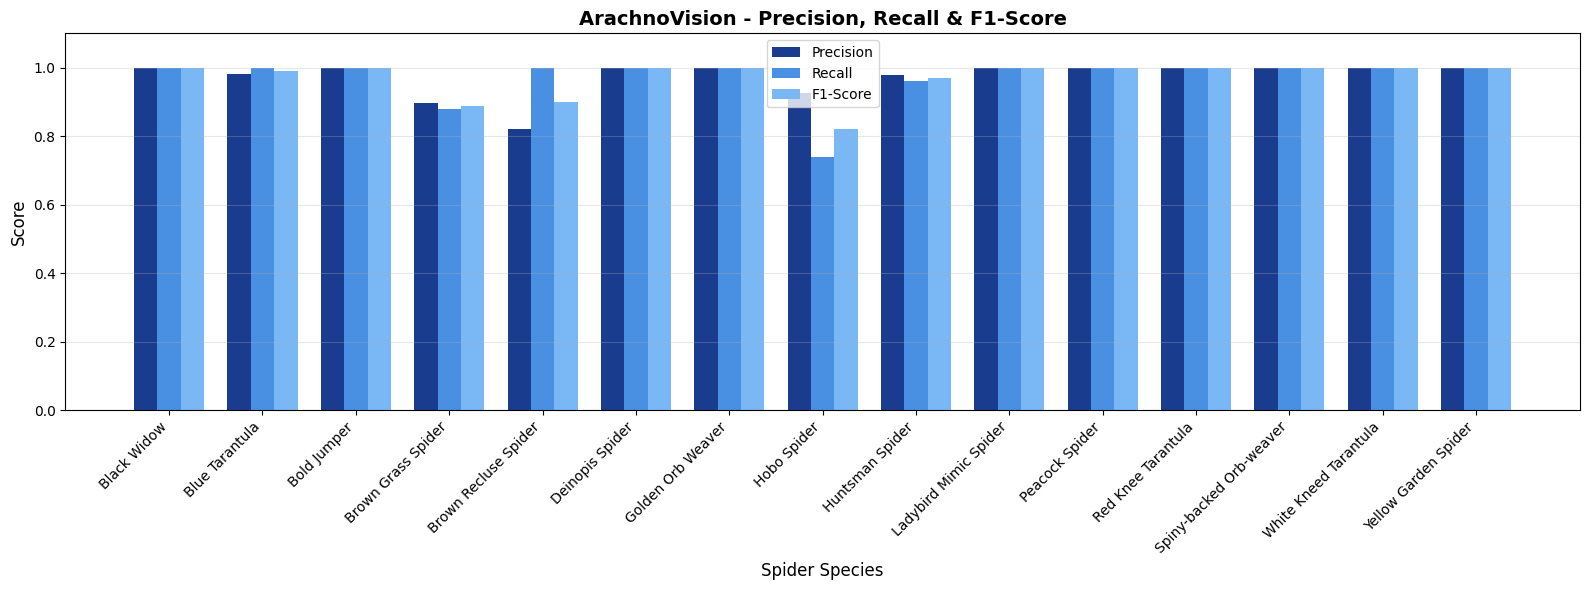

✅ Graph saved to Drive!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    true_classes, predicted_classes
)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#1a3c8f')
bars2 = ax.bar(x, recall, width, label='Recall', color='#4a90e2')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#7ab8f5')

ax.set_xlabel('Spider Species', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('ArachnoVision - Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/precision_recall_f1.png', dpi=150)
plt.show()
print("✅ Graph saved to Drive!")

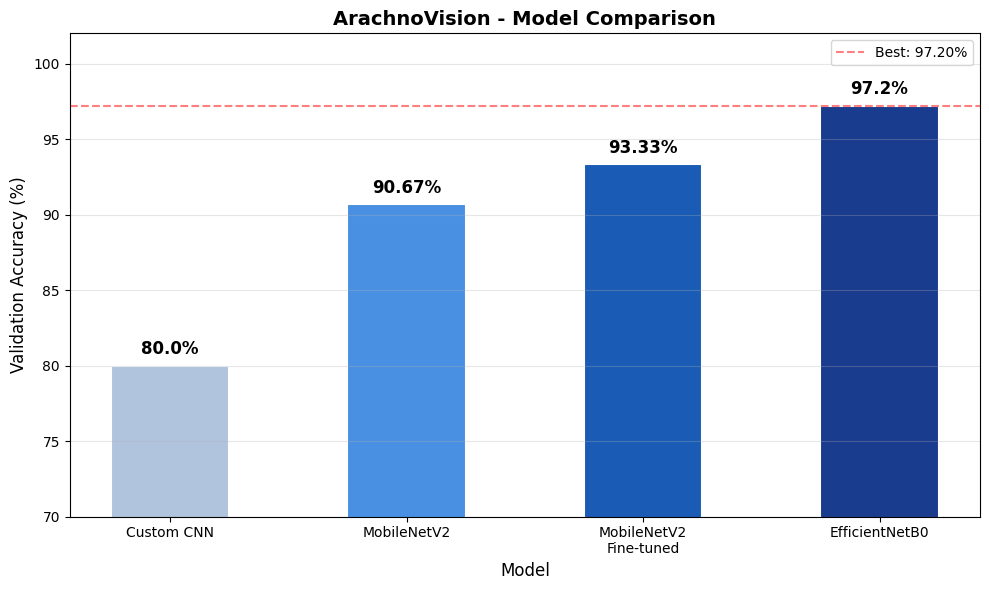

✅ Model Comparison Graph saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Custom CNN', 'MobileNetV2', 'MobileNetV2\nFine-tuned', 'EfficientNetB0']
accuracies = [80.00, 90.67, 93.33, 97.20]
colors = ['#b0c4de', '#4a90e2', '#1a5cb5', '#1a3c8f']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('ArachnoVision - Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(70, 102)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=97.20, color='red', linestyle='--', alpha=0.5, label='Best: 97.20%')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=150)
plt.show()
print("✅ Model Comparison Graph saved!")

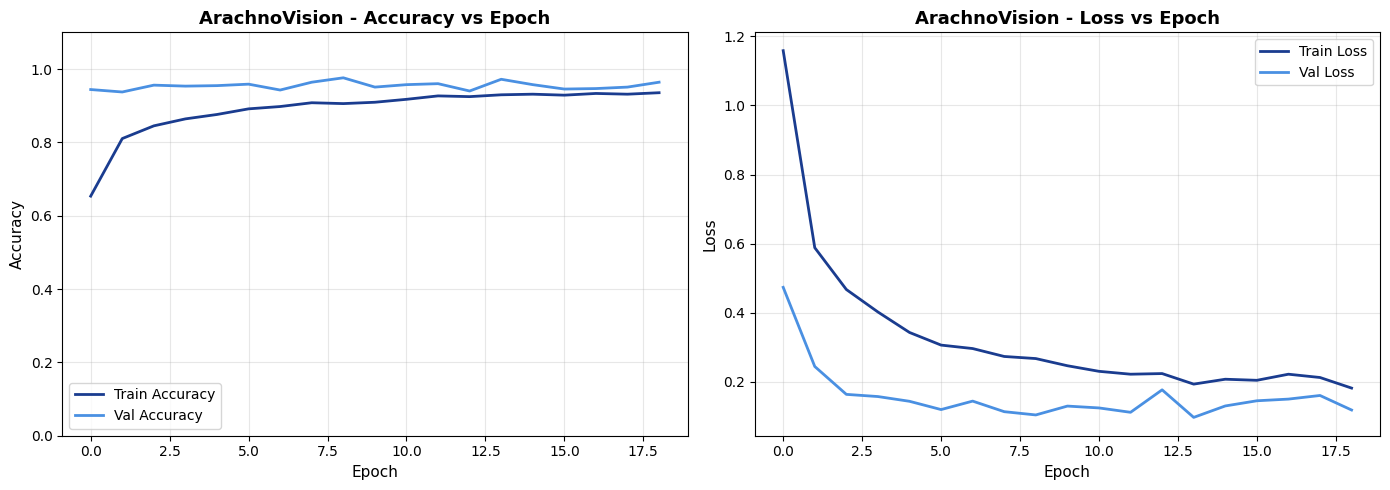

✅ Graph saved to Drive!


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
ax1.plot(history3.history['accuracy'], label='Train Accuracy', color='#1a3c8f', linewidth=2)
ax1.plot(history3.history['val_accuracy'], label='Val Accuracy', color='#4a90e2', linewidth=2)
ax1.set_title('ArachnoVision - Accuracy vs Epoch', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1.1)

# Loss Graph
ax2.plot(history3.history['loss'], label='Train Loss', color='#1a3c8f', linewidth=2)
ax2.plot(history3.history['val_loss'], label='Val Loss', color='#4a90e2', linewidth=2)
ax2.set_title('ArachnoVision - Loss vs Epoch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/accuracy_loss_graph.png', dpi=150)
plt.show()
print("✅ Graph saved to Drive!")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image
import os, random

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

test_dir = 'dataset/test'
spider_types = os.listdir(test_dir)

for i, spider in enumerate(random.sample(spider_types, 15)):
    img_folder = f'{test_dir}/{spider}'
    img_file = random.choice(os.listdir(img_folder))
    img_path = f'{img_folder}/{img_file}'

    img = Image.open(img_path)
    img_resized = img.resize((224, 224))
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array, verbose=0)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    predicted = class_names[class_idx]

    color = 'green' if predicted == spider else 'red'
    status = '✓' if predicted == spider else '✗'

    axes[i].imshow(img)
    axes[i].set_title(f'{status} Actual: {spider}\nPred: {predicted}\n({confidence:.1f}%)',
                      color=color, fontsize=8, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('ArachnoVision - Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_predictions.png', dpi=150)
plt.show()
print("✅ Sample Predictions saved to Drive!")

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image

def predict_spider(img):
    if img is None:
        return {}
    img_resized = img.resize((224, 224))
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array, verbose=0)

    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    results = {}
    for idx in top3_idx:
        results[class_names[idx]] = float(prediction[0][idx])

    return results

css = """
body {
    background-color: #f0f4ff !important;
    font-family: 'Segoe UI', sans-serif;
}

.gradio-container {
    max-width: 900px !important;
    margin: auto !important;
    background: white !important;
    border-radius: 20px !important;
    box-shadow: 0 4px 20px rgba(0,0,255,0.1) !important;
    padding: 30px !important;
}

h1 {
    color: #1a3c8f !important;
    text-align: center !important;
    font-size: 2.5em !important;
    font-weight: 800 !important;
}

.description {
    color: #4a6fa5 !important;
    text-align: center !important;
    font-size: 1.1em !important;
}

button.primary {
    background: linear-gradient(135deg, #1a3c8f, #4a90e2) !important;
    color: white !important;
    border-radius: 10px !important;
    font-size: 1.1em !important;
    padding: 12px 30px !important;
}

.label-container {
    background: #f0f4ff !important;
    border-radius: 10px !important;
    padding: 15px !important;
}
"""

app = gr.Interface(
    fn=predict_spider,
    inputs=gr.Image(
        type='pil',
        label="Upload Spider Image",
    ),
    outputs=gr.Label(
        num_top_classes=3,
        label="🔍 Identified Spider"
    ),
    title="🕷️ ArachnoVision",
    description="### AI-Powered Spider Identification System\nUpload a spider image and our model will identify the species with **97.20% accuracy!**",
    css=css,
    theme=gr.themes.Base(
        primary_hue="blue",
        secondary_hue="indigo",
        neutral_hue="slate",
    ).set(
        button_primary_background_fill="linear-gradient(135deg, #1a3c8f, #4a90e2)",
        button_primary_text_color="white",
        block_title_text_color="#1a3c8f",
        block_label_text_color="#4a6fa5",
    )
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://42b9b3df39fb991780.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
